In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:14pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:80px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:2px;}
table.dataframe{font-size:5xpt;} 
</style>
"""))

#  딥러닝 : 데이터의 규칙성을 추출
- 응용분야 : 글씨인식, 문장분류, 값예측, 질병진단, 얼굴인식
- ML/DL의 종류
    * 지도학습(입력=독립변수, 타겟=종속변수)
        * 분류분석(타겟변수가 category변수인 분석. 다중분류와 이진분류) vs 회귀분석
    * 비지도학습(입력변수)
        * 군집화
    * 강화학습

- 지도학습에서의 딥러닝 프로그래밍 방식
    1. 데이터 확보
    2. 데이터 전처리 : 결측치 처리, 스케일 조정, 인코딩처리(라벨인코딩, 원핫인코딩), 학습, 검증, 시험 데이터셋 분리
    3. 모델 구성
    4. 모델 학습 과정 설정
    5. 모델 학습시키기(훈련, 검증 데이터셋)
    6. 모델 평가(시험 데이터셋)
    7. 모델 저장 / 사용(입력값이 주어지면 예측갑을 받기)

In [2]:
from tensorflow.keras.utils import to_categorical # 분류분석시 원핫인코딩(to_categorical추천)
import pandas as pd # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model # 모델 생성, 모델 load
from tensorflow.keras.layers import Dense, Input # 모델에 층을 쌓기 위해 
import numpy as np 

## 1. 데이터셋 확보

## 2. 데이터 전처리


###  # 학습데이터 = 훈련데이터셋

In [34]:
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,3,4,5,6,7,8,9,10]*10)

### # 검증데이터, 시험데이터셋

In [35]:
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,3,4,5,6,7,8,9,10])

### # 인코딩 종류
    - 라벨인코딩 = 문자를 숫자로
    - 원핫인코딩 = 값의 갯수만금 열을 만들고, 해당 범주에 해당하는 열만 1을 나머지열은 0을

In [30]:
data = np.array(['aa', 'bb', 'cc', 'bb', 'bb'])
print('원 데이터 :', data)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le.fit(data)
# labeling_data = le.transform(data)

labeling_data = le.fit_transform(data)
print('라벨인코딩된 데이터 : ', labeling_data)

# onehot_encoding_data = to_categorical(data) # 에러남
onehot_encoding_data1 = to_categorical(labeling_data)
print('라벨인코딩된 데이터 : \n', onehot_encoding_data1)

onehot_encoding_data2 = pd.get_dummies(data)
print('라벨인코딩된 데이터 : \n', onehot_encoding_data2)

원 데이터 : ['aa' 'bb' 'cc' 'bb' 'bb']
라벨인코딩된 데이터 :  [0 1 2 1 1]
라벨인코딩된 데이터 : 
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
라벨인코딩된 데이터 : 
    aa  bb  cc
0   1   0   0
1   0   1   0
2   0   0   1
3   0   1   0
4   0   1   0


In [31]:
data = np.array([1,2,3,4,5])
categorical_onehot = to_categorical(data)
print('to_categorical 이용 \n', categorical_onehot)
getdummies_onehot = pd.get_dummies(data)
print('get_dummies 이용\n', getdummies_onehot)

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
get_dummies 이용
    1  2  3  4  5
0  1  0  0  0  0
1  0  1  0  0  0
2  0  0  1  0  0
3  0  0  0  1  0
4  0  0  0  0  1


In [36]:
# 분류분석을 위한 종속(타겟)변수의 원핫인코딩
Y_train = to_categorical(y_train, 11)
Y_val = to_categorical(y_val)

In [37]:
# 딥러닝 모델에 사용될 데이터
x_train.shape, Y_train.shape, x_val.shape, Y_val.shape

((90,), (90, 11), (9,), (9, 11))

In [38]:
Y_val[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

# 3. 모델 구성

In [42]:
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38, activation='sigmoid')) # 활성화함수 : relu, elu, tanh, sigmoid, softmax
model.add(Dense(64, activation='elu'))
model.add(Dense(32, activation='elu'))
model.add(Dense(11, activation='softmax')) # 다중분류에서의 출력층 활성화 함수 : softmax
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 38)                76        
                                                                 
 dense_10 (Dense)            (None, 64)                2496      
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dense_12 (Dense)            (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습과정 설정

- 회귀 분석에서의 loss : mse, mae, rmse
- 다중 분류에서의 loss : categorical_crossentropy 
- 이진 분류에서의 loss : binary_crossentropy
- 분류 분석에서의 metrics(평가지표) : accuracy, recall, precision

In [43]:
model.compile(loss='categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

# 5. 모델 학습시키기

In [45]:
hist = model.fit(x_train, Y_train, # 학습데이터셋(입력변수와 타겟변수)
                 epochs=300,       # 학습횟수
                 batch_size=10,
                 validation_data=(x_val,Y_val),
                 verbose=1)
# verbers=0 : 학습로그출력없음 / 1:기본값 출력 / 2:자세한로그출력

Epoch 1/300
9/9 [==============================] - 0s 44ms/step - loss: 0.0032 - accuracy: 1.0000 - val_loss: 0.0032 - val_accuracy: 1.0000
Epoch 2/300
9/9 [==============================] - 0s 25ms/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0031 - val_accuracy: 1.0000
Epoch 3/300
9/9 [==============================] - 0s 25ms/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0031 - val_accuracy: 1.0000
Epoch 4/300
9/9 [==============================] - 0s 28ms/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0031 - val_accuracy: 1.0000
Epoch 5/300
9/9 [==============================] - 0s 24ms/step - loss: 0.0031 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 6/300
9/9 [==============================] - 0s 24ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 7/300
9/9 [==============================] - 0s 25ms/step - loss: 0.0030 - accuracy: 1.0000 - val_loss: 0.0030 - val_accuracy: 1.0000
Epoch 8/300
9/9 [===

9/9 [==============================] - 0s 20ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0018 - val_accuracy: 1.0000
Epoch 60/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0018 - val_accuracy: 1.0000
Epoch 61/300
9/9 [==============================] - 0s 18ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0018 - val_accuracy: 1.0000
Epoch 62/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 63/300
9/9 [==============================] - 0s 20ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 64/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 65/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 66/300
9/9 [========

9/9 [==============================] - 0s 20ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 20ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 20ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 19ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 20ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0011 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 20ms/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0010 - val_accuracy: 1.0000
Epoch 124/300
9/9 [=

9/9 [==============================] - 0s 20ms/step - loss: 7.2245e-04 - accuracy: 1.0000 - val_loss: 7.1740e-04 - val_accuracy: 1.0000
Epoch 173/300
9/9 [==============================] - 0s 19ms/step - loss: 7.1642e-04 - accuracy: 1.0000 - val_loss: 7.1152e-04 - val_accuracy: 1.0000
Epoch 174/300
9/9 [==============================] - 0s 20ms/step - loss: 7.1150e-04 - accuracy: 1.0000 - val_loss: 7.0629e-04 - val_accuracy: 1.0000
Epoch 175/300
9/9 [==============================] - 0s 19ms/step - loss: 7.0525e-04 - accuracy: 1.0000 - val_loss: 7.0149e-04 - val_accuracy: 1.0000
Epoch 176/300
9/9 [==============================] - 0s 19ms/step - loss: 6.9990e-04 - accuracy: 1.0000 - val_loss: 6.9630e-04 - val_accuracy: 1.0000
Epoch 177/300
9/9 [==============================] - 0s 19ms/step - loss: 6.9523e-04 - accuracy: 1.0000 - val_loss: 6.9113e-04 - val_accuracy: 1.0000
Epoch 178/300
9/9 [==============================] - 0s 19ms/step - loss: 6.9223e-04 - accuracy: 1.0000 - val_loss

Epoch 227/300
9/9 [==============================] - 0s 18ms/step - loss: 4.9020e-04 - accuracy: 1.0000 - val_loss: 4.8512e-04 - val_accuracy: 1.0000
Epoch 228/300
9/9 [==============================] - 0s 22ms/step - loss: 4.8550e-04 - accuracy: 1.0000 - val_loss: 4.8282e-04 - val_accuracy: 1.0000
Epoch 229/300
9/9 [==============================] - 0s 22ms/step - loss: 4.8160e-04 - accuracy: 1.0000 - val_loss: 4.7752e-04 - val_accuracy: 1.0000
Epoch 230/300
9/9 [==============================] - 0s 20ms/step - loss: 4.7942e-04 - accuracy: 1.0000 - val_loss: 4.7466e-04 - val_accuracy: 1.0000
Epoch 231/300
9/9 [==============================] - 0s 19ms/step - loss: 4.7834e-04 - accuracy: 1.0000 - val_loss: 4.7235e-04 - val_accuracy: 1.0000
Epoch 232/300
9/9 [==============================] - 0s 20ms/step - loss: 4.7099e-04 - accuracy: 1.0000 - val_loss: 4.6991e-04 - val_accuracy: 1.0000
Epoch 233/300
9/9 [==============================] - 0s 20ms/step - loss: 4.7074e-04 - accuracy: 1.0

9/9 [==============================] - 0s 19ms/step - loss: 3.3962e-04 - accuracy: 1.0000 - val_loss: 3.3751e-04 - val_accuracy: 1.0000
Epoch 282/300
9/9 [==============================] - 0s 19ms/step - loss: 3.3869e-04 - accuracy: 1.0000 - val_loss: 3.3696e-04 - val_accuracy: 1.0000
Epoch 283/300
9/9 [==============================] - 0s 19ms/step - loss: 3.3698e-04 - accuracy: 1.0000 - val_loss: 3.3447e-04 - val_accuracy: 1.0000
Epoch 284/300
9/9 [==============================] - 0s 19ms/step - loss: 3.3515e-04 - accuracy: 1.0000 - val_loss: 3.3232e-04 - val_accuracy: 1.0000
Epoch 285/300
9/9 [==============================] - 0s 17ms/step - loss: 3.3157e-04 - accuracy: 1.0000 - val_loss: 3.2900e-04 - val_accuracy: 1.0000
Epoch 286/300
9/9 [==============================] - 0s 22ms/step - loss: 3.2934e-04 - accuracy: 1.0000 - val_loss: 3.2765e-04 - val_accuracy: 1.0000
Epoch 287/300
9/9 [==============================] - 0s 20ms/step - loss: 3.2711e-04 - accuracy: 1.0000 - val_loss

# 6. 모델 평가하기(모델 학습과정 살펴보고, evaluate)

In [47]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

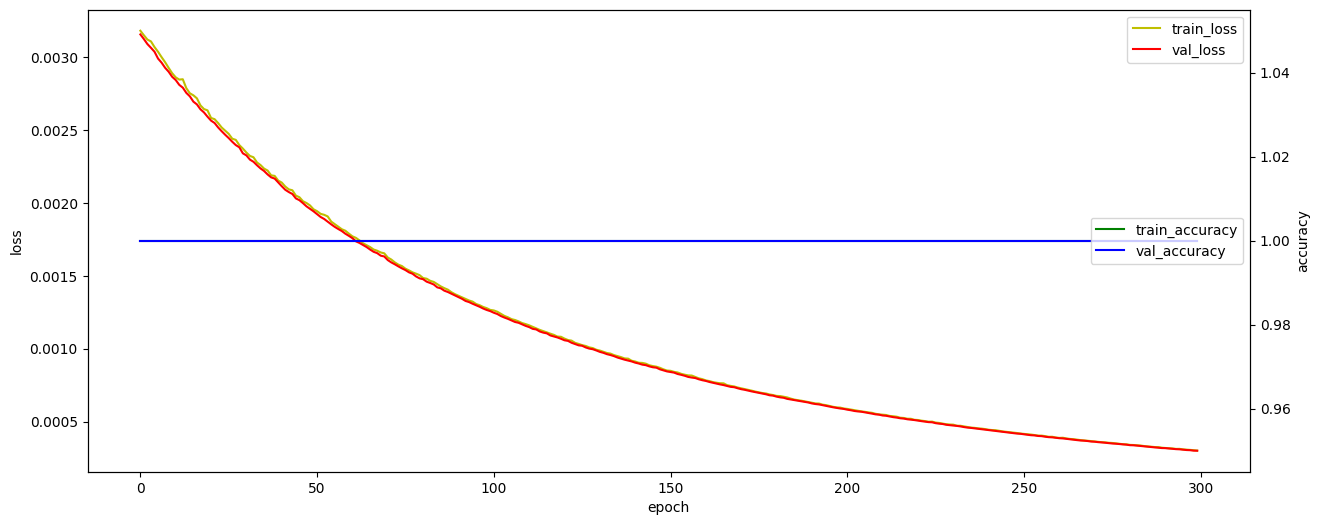

In [48]:
# 학습과정 살펴보기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [50]:
# 모델 평가하기
score = model.evaluate(x_val, Y_val, batch_size=3)
print('loss : ', score[0])
print('accuracy : ', score[1])

3/3 [==============================] - 0s 7ms/step - loss: 2.9955e-04 - accuracy: 1.0000
loss :  0.00029955481295473874
accuracy :  1.0


# 7. 모델 저장하기

In [51]:
model.save('model/02_deep.h5') # 모델 저장 파일 : h5이나 keras

In [52]:
# 저장된 모델 사용하기
model1 = load_model('model/02_deep.h5')

# 7. 모델 사용하기

In [55]:
h = model.predict(np.array([5]))
h.argmax()

1/1 [==============================] - 0s 37ms/step


6

In [56]:
model.predict(np.array([5])).argmax()

1/1 [==============================] - 0s 38ms/step


6

In [57]:
# 몇 %확률로 5라고 예측했나?
h[0, h.argmax()]*100

99.97652173042297

In [58]:
h[0, [4,5,6]]

array([1.7124813e-10, 1.0856302e-04, 9.9976522e-01], dtype=float32)